# Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression

from utils import *

## Load data

In [2]:
# Define paths and file names
root_path = 'data/'
data_path = root_path + '7194372/'
tf_filenames_dict = {
    'maize'     : 'Zma_TF_list.txt',
    'rice'      : 'Osj_TF_list.txt',
    'sorghum'   : 'Sbi_TF_list.txt'
}

Load expression data

In [3]:
# Load and format expression data
exp_data = pd.read_csv(f"{data_path}Input_data-2022-001/orthogroup_expression/"
                       "zma_osa_sbi_ortho_hai_expr_all.tsv", sep='	')
exp_data.columns = [col.lower().replace('.','_') for col in exp_data.columns]
exp_data.head()

,gene_id,mean_leaf_section_1,mean_leaf_section_2,mean_leaf_section_3,mean_leaf_section_4,mean_leaf_section_6,mean_leaf_section_7,mean_leaf_section_8,mean_leaf_section_9,mean_leaf_section_10,...,srr6257228_mean,srr6257231_mean,srr8401514_mean,srr9202997_mean,srr9202998_mean,srr9203000_mean,srr9203001_mean,srr9203002_mean,srr9203003_mean,srr9203005_mean
0,ORTHO04M000001,4.546497,6.520382,6.253503,6.826752,6.745223,3.363057,5.000000,4.141401,4.249045,...,2.605618,1.835184,1.601559,2.432007,1.622150,2.686271,1.748511,2.181920,2.756412,2.326934
1,ORTHO04M000002,5.568790,10.509554,11.924204,7.954140,3.438217,0.000000,1.582803,1.537580,1.446497,...,10.177549,3.879458,0.796495,6.654203,1.350818,4.058331,6.377811,3.781891,2.106601,6.723717
2,ORTHO04M000003,5.755689,4.791018,4.871257,5.071257,4.532335,0.161677,3.382036,2.816168,3.359880,...,28.256274,29.906009,3.003803,9.677179,7.787140,10.327200,13.166616,9.940935,9.422623,13.480669
3,ORTHO04M000004,5.931737,7.356886,9.832934,9.923952,6.170659,0.000000,3.388623,2.559281,2.589820,...,5.598559,7.510683,2.290947,3.690457,2.634284,4.460366,4.990626,3.275099,3.170542,5.966543
4,ORTHO04M000005,22.267045,31.086364,33.167045,26.302273,12.117045,2.005682,7.471591,6.215909,5.164773,...,8.677945,10.664965,1.042287,10.677949,1.715857,7.845614,13.432008,10.941222,4.615420,18.174727


Load TF data

In [4]:
# Load TF data from PlantDB
tf_data_dict = {}
all_tf_gene_ids = []
for crop, filename in tf_filenames_dict.items():
    # Load and format data
    temp_df = pd.read_csv(f'{data_path}{filename}', sep='\t')
    temp_df.columns = [col.lower().replace('.','_') for col in temp_df.columns]
    
    # Add data to dictionary and gene IDs to list
    tf_data_dict[crop] = temp_df
    all_tf_gene_ids += tf_data_dict[crop]['gene_id'].tolist()

# Get a set of unique TF gene IDs
all_tf_gene_ids = set(all_tf_gene_ids)
print(len(all_tf_gene_ids))

6010


Load mapping data

In [5]:
# Load and format ortholog mapping data
map_data = pd.read_csv(f'{data_path}Input_data-2022-001/orthogroups/'
                       'maize_outward/orthos_maize_outward.tsv', sep='\t')
map_data.columns = [col.lower().replace('#','') for col in map_data.columns]
map_data['og'] = map_data.og.apply(lambda x: f"ORTHO04M{x[2:].zfill(6)}")

# Get orthologous gene IDs
tf_ortho_ids = (
    map_data.query('orthologous_gene in @all_tf_gene_ids')
    ['og'].unique().tolist()
)
print(len(tf_ortho_ids))

1591


# Baseline Model

## Explanation

Baseline model is a Partial Least Squares Regression Model

- **target** ($X_{nonTF}$): gene expression matrix (GEM) with orthogroups not assciated with transcription factors (TFs).

- **predictor** ($X_{TF}$): GEM with only TF orthogroups.

- **Goal**: predict col. of $X_{nonTF}$ with a combination from $X_{TF}$.

Other notes:
- Transforms space of predictors in $X_{TF}$ to orthogonal variables (linear, independent).
- Used PLSA algorithm where Y and $X_{TF}$ variables spaces are modeled simultaneaously.
- They used corss-validation to find optimal number of componenets
- Model evaluation: spearman rank correlation
- Results: predicted expression profila of all genes across all experiments and compared to observed abundances.

## PLS regression model

In [6]:
X_all = (
    exp_data.query('gene_id in @tf_ortho_ids')
    .set_index('gene_id').T.copy().fillna(0)
)
Y_all = (
    exp_data.query('gene_id not in @tf_ortho_ids')
    .set_index('gene_id').T.copy().fillna(0)
)

# Implement the 80:20 Train-Test Split across experiments
X_train, X_test, Y_train, Y_test = train_test_split(X_all, Y_all, 
                                                    test_size=0.20, 
                                                    random_state=42)

In [7]:
# components = 3
pls = PLSRegression(n_components=3)

# Fit the model: Using the TF "Control Center" to predict the "Factory" output
pls.fit(X_all, Y_all)

# This gives you the 'estimated' expression data for target genes
Y_pred = pls.predict(X_all)

# Calculate how well the TFs predict each target gene (R-squared)
score = pls.score(X_all, Y_all)
print(f"Total variance explained: {score:.4f}")

Total variance explained: 0.2304


In [8]:
# Ensure Y is a numpy array for consistent operations with Y_pred
Y_true = Y_all.to_numpy()

# Initialize a list to store Spearman correlation coefficients for each target gene
spearman_correlations = []

# Iterate through each target gene (column) to calculate correlation
# Y_pred and Y_true have shape (n_samples, n_features)
for i in range(Y_true.shape[1]):
    # Calculate Spearman correlation for the i-th target gene
    # between its actual values and predicted values across all samples
    corr, _ = spearmanr(Y_true[:, i], Y_pred[:, i])
    spearman_correlations.append(corr)

# Convert the list of correlations to a pandas Series for easier analysis
spearman_series = pd.Series(spearman_correlations, index=Y_all.columns)

# Display descriptive statistics of the correlations
print("Descriptive Statistics of Spearman Correlations for Target Genes:")
display(spearman_series.describe())

# Optionally, display the first few correlations
print("\nTop 10 Spearman Correlations:")
display(spearman_series.nlargest(10))

print("\nBottom 10 Spearman Correlations (can indicate negative correlation or poor prediction):")
display(spearman_series.nsmallest(10))

mean_rho = np.nanmean(spearman_series)
print(f"Mean Spearman Correlation: {mean_rho:.2f}")

Descriptive Statistics of Spearman Correlations for Target Genes:


count    17893.000000
mean         0.473699
std          0.292592
min         -0.392400
25%          0.178542
50%          0.499115
75%          0.747398
max          0.962975
dtype: float64


Top 10 Spearman Correlations:


gene_id
ORTHO04M000688    0.962975
ORTHO04M002110    0.959836
ORTHO04M003276    0.957315
ORTHO04M001953    0.952293
ORTHO04M001323    0.951650
ORTHO04M003472    0.951615
ORTHO04M004052    0.951573
ORTHO04M000592    0.951126
ORTHO04M006083    0.950831
ORTHO04M002236    0.950744
dtype: float64


Bottom 10 Spearman Correlations (can indicate negative correlation or poor prediction):


gene_id
ORTHO04M008117   -0.392400
ORTHO04M011036   -0.347512
ORTHO04M010514   -0.335474
ORTHO04M000289   -0.324260
ORTHO04M010880   -0.293288
ORTHO04M011091   -0.280535
ORTHO04M001722   -0.279296
ORTHO04M008985   -0.252235
ORTHO04M010302   -0.248333
ORTHO04M009502   -0.244556
dtype: float64

Mean Spearman Correlation: 0.47


# Graph Autoencoder (GAE)

## Data prep

Only use Arabidopsis map data

In [9]:
# Create a dictionary to map orthologous gene IDs to OG
map_data_ath = map_data.query('orthologous_species == "ath"').copy()
# at_to_ortho_dict = map_data_ath.set_index('orthologous_gene')['og'].to_dict()
map_data_ath = map_data_ath[['og', 'orthologous_gene']]

Load iGRN network

In [10]:
# Load iGRN network
net_data = pd.read_csv(f"{root_path}Data_file1_iGRN_supervised_network_support.txt", 
                       sep='\t', header=None, usecols=[0, 1, 2])
net_data.columns = ['Source_AT', 'Target_AT', 'Weight']

# Threshold the network (like stated in paper)
net_data = net_data.query('Weight >= 0.9').copy()

# Map the network to Ortholog Space
# NOTE: using merge for one-to-many mapping (one AT can map to many OGs)
net_data = net_data.merge(
    map_data_ath,
    left_on='Source_AT',
    right_on='orthologous_gene',
    how='inner' 
)
net_data = (net_data.rename(columns={'og': 'Source_Ortho'})
            .drop(columns=['orthologous_gene']))
net_data = net_data.merge(
    map_data_ath,
    left_on='Target_AT',
    right_on='orthologous_gene',
    how='inner' 
)
net_data = (net_data.rename(columns={'og': 'Target_Ortho'})
            .drop(columns=['orthologous_gene']))

# Build PyTorch Geometric Edge Index
gene_to_index = {gene_id: i for i, gene_id in enumerate(exp_data['gene_id'])}

# Map to indices
net_data['Source_Idx'] = net_data['Source_Ortho'].map(gene_to_index)
net_data['Target_Idx'] = net_data['Target_Ortho'].map(gene_to_index)

# Drop any edges where a node isn't in the expression data
net_data = net_data.dropna(subset=['Source_Idx', 'Target_Idx'])

print(net_data.shape)
print(net_data.head())

(8574, 7)
   Source_AT  Target_AT    Weight    Source_Ortho    Target_Ortho  Source_Idx  \
0  AT4G36920  AT3G61470  0.985894  ORTHO04M000483  ORTHO04M002736       464.0   
1  AT4G36920  AT3G61470  0.985894  ORTHO04M000483  ORTHO04M004007       464.0   
2  AT4G36920  AT3G61470  0.985894  ORTHO04M000483  ORTHO04M009921       464.0   
5  AT4G36920  AT3G61470  0.985894  ORTHO04M008323  ORTHO04M002736      7931.0   
6  AT4G36920  AT3G61470  0.985894  ORTHO04M008323  ORTHO04M004007      7931.0   

   Target_Idx  
0      2619.0  
1      3826.0  
2      9163.0  
5      2619.0  
6      3826.0  


Create edge

In [11]:
# Convert mapped string IDs to integer row indices
source_indices = net_data['Source_Idx'].astype(int).values
target_indices = net_data['Target_Idx'].astype(int).values

# Create the 2D edge_index tensor
edge_index = torch.tensor(np.array([source_indices, target_indices]), 
                          dtype=torch.long)
print(f"Constructed edge_index with shape: {edge_index.shape}")

Constructed edge_index with shape: torch.Size([2, 8574])


Split data into train and test

In [31]:
# Fill missing values with 0
clean_exp_data = np.log1p(exp_data.fillna(0.0).set_index('gene_id'))

# Identify the experiment columns
experiment_cols = clean_exp_data.columns.tolist()

# Perform an 80:20 split on the column names (experiments)
train_exps, test_exps = train_test_split(experiment_cols, test_size=0.20, 
                                         random_state=42)

# Create a masked copy of the expression data for training
train_exp_data_masked = clean_exp_data.copy()
test_exp_data_masked = clean_exp_data.copy()

# Mask the test experiments with 0.0 to prevent data leakage
train_exp_data_masked[test_exps] = 0.0

# Scale the features using ONLY the masked training data
scaler = StandardScaler()
scaled_train_features = scaler.fit_transform(train_exp_data_masked)

# Convert to PyTorch Tensor
X_train_tensor = torch.tensor(scaled_train_features, dtype=torch.float32)

# 2. Put the scaled data back into a DataFrame so we can easily slice it by name
scaled_train_df = pd.DataFrame(
    scaled_train_features, 
    index=clean_exp_data.index, 
    columns=clean_exp_data.columns
)

# 3. Identify only the Target Genes (exclude the TFs)
target_genes = [g for g in clean_exp_data.index if g not in tf_ortho_ids]

# 4. Slice the DataFrame: Target Genes (rows) and ONLY Training Experiments (columns)
Y_train_df = scaled_train_df.loc[target_genes, train_exps]

# 5. Convert to PyTorch Tensor
Y_train_tensor = torch.tensor(Y_train_df.to_numpy(), dtype=torch.float32)

print(f"Masked Feature Tensor Shape (X_train_tensor): {X_train_tensor.shape}")
print(f"Number of Masked Test Experiments: {len(test_exps)}")

Masked Feature Tensor Shape (X_train_tensor): torch.Size([18449, 698])
Number of Masked Test Experiments: 140


## Training

Build model

In [32]:
# Initialize Model and Optimizer
in_channels = X_train_tensor.shape[1] # Number of expression experiments
out_channels = 32 # The size of the latent embedding space

# Instantiate the Graph Autoencoder
model = GAE(ShallowEncoder(in_channels, out_channels))

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
X_train_tensor = X_train_tensor.to(device)
edge_index = edge_index.to(device)

Train

In [33]:
gae_model, gae_losses = train_gae(model, optimizer, X_train_tensor, edge_index, 
                                  epochs=25)

Epoch: 001 | GAE Recon Loss: 12.7562
Epoch: 010 | GAE Recon Loss: 1.7354
Epoch: 020 | GAE Recon Loss: 1.1671


Loss graph

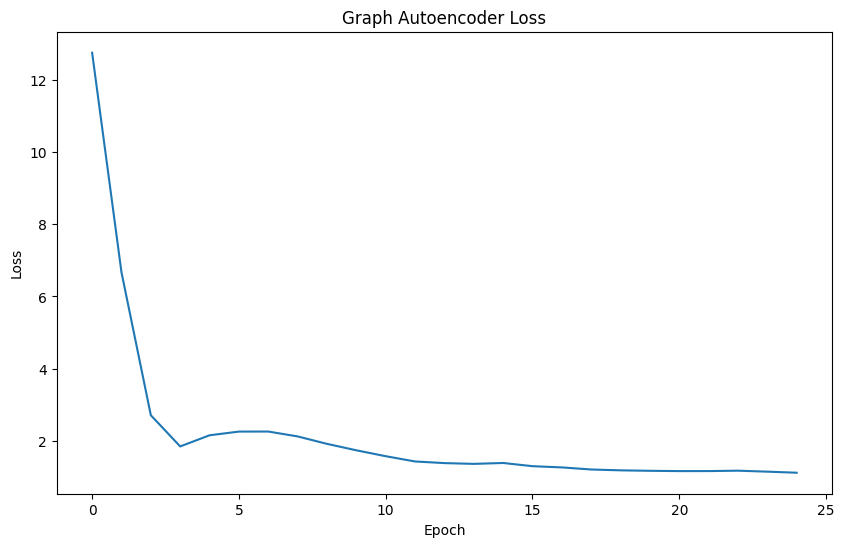

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(gae_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Graph Autoencoder Loss')
plt.show()

Once trained, generate the final embeddings (detached from the gradient graph)

In [35]:
gae_model.eval()
with torch.no_grad():
    Z_train = model.encode(X_train_tensor, edge_index).cpu().numpy()

# Multilayer Perceptron (MLP)

MLP for estimating gene expression

Split data

In [36]:
# Get embeddings from GAE
Z_tensor = torch.tensor(Z_train, dtype=torch.float32).to(device)

# Get the row indices for the Target Genes
target_indices = [gene_to_index[g] for g in Y_train_df.index 
                  if g in gene_to_index]

# MLP Inputs: The 32-D embeddings of the TARGET Genes
mlp_inputs = Z_tensor[target_indices]

# MLP Targets: The actual expression values of the TARGET Genes
mlp_targets = Y_train_tensor.to(device)

print(f"MLP Input Shape: {mlp_inputs.shape}")
print(f"MLP Target Shape: {mlp_targets.shape}")

# Split our Target Genes (rows) into 80% Train and 20% Test
X_train_genes, X_test_genes, Y_train_genes, Y_test_genes = train_test_split(
    mlp_inputs.cpu().numpy(), 
    mlp_targets.cpu().numpy(), 
    test_size=0.20, 
    random_state=42
)

# Convert back to tensors
X_train_genes = torch.tensor(X_train_genes, dtype=torch.float32).to(device)
X_test_genes = torch.tensor(X_test_genes, dtype=torch.float32).to(device)
Y_train_genes = torch.tensor(Y_train_genes, dtype=torch.float32).to(device)
Y_test_genes = torch.tensor(Y_test_genes, dtype=torch.float32).to(device)

MLP Input Shape: torch.Size([17893, 32])
MLP Target Shape: torch.Size([17893, 558])


## Training

In [37]:
# Initialize MLP
mlp_model = ExpressionMLP(
    input_dim=32, 
    hidden_dim=512, 
    output_dim=558
).to(device)

# Train on the 80% split
trained_mlp, mlp_losses = train_mlp(
    mlp_model, 
    X_train_genes, 
    Y_train_genes, 
    epochs=100,
    lr=0.001
)

MLP Epoch: 001 | MSE Loss: 0.9982
MLP Epoch: 020 | MSE Loss: 0.7862
MLP Epoch: 040 | MSE Loss: 0.3415
MLP Epoch: 060 | MSE Loss: 0.3378
MLP Epoch: 080 | MSE Loss: 0.3390
MLP Epoch: 100 | MSE Loss: 0.3388


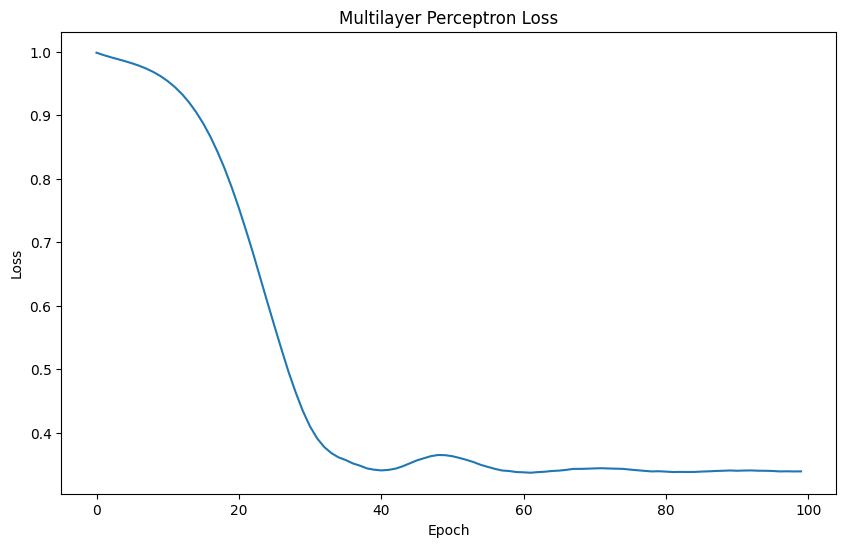

In [74]:
plt.figure(figsize=(10, 6))
plt.plot(mlp_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Multilayer Perceptron Loss')
plt.show()

# Evaluation

In [53]:
results_df, (train_tar, train_pred, test_tar, test_pred) = get_mlp_results(
    trained_mlp, Y_train_genes, Y_test_genes, 
    X_train_genes, X_test_genes, scaler, train_exps, 
    clean_exp_data.columns.tolist()
)
results_df.round(4)

,Metric,Train (Seen Genes),Test (Unseen Genes)
0,MSE (Scaled),0.3368,0.3313
1,MAE (TPM),17.1876,16.9721
2,MSE (TPM),74725.8769,67570.9176
3,Spearman Correlation,0.8152,0.8142


In [54]:
print(results_df.round(4))

                 Metric  Train (Seen Genes)  Test (Unseen Genes)
0          MSE (Scaled)              0.3368               0.3313
1             MAE (TPM)             17.1876              16.9721
2             MSE (TPM)          74725.8769           67570.9176
3  Spearman Correlation              0.8152               0.8142


Dataset has +10K points, only plotting a random sample of 3K for better visualizations.

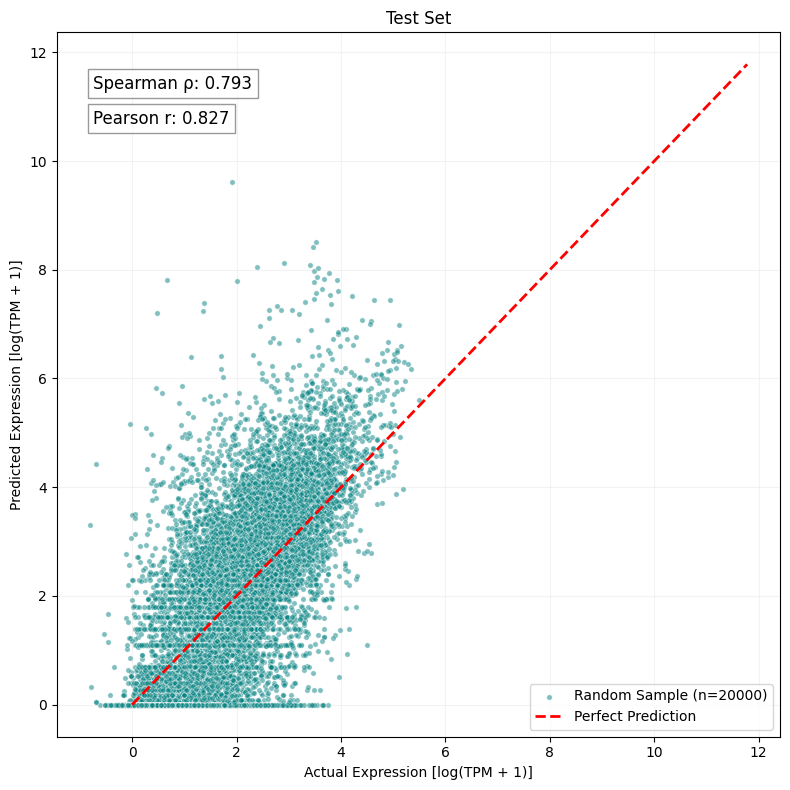

In [78]:
plot_expression_predictions(test_tar, test_pred, title='Test Set', 
                            sample_size=20000)

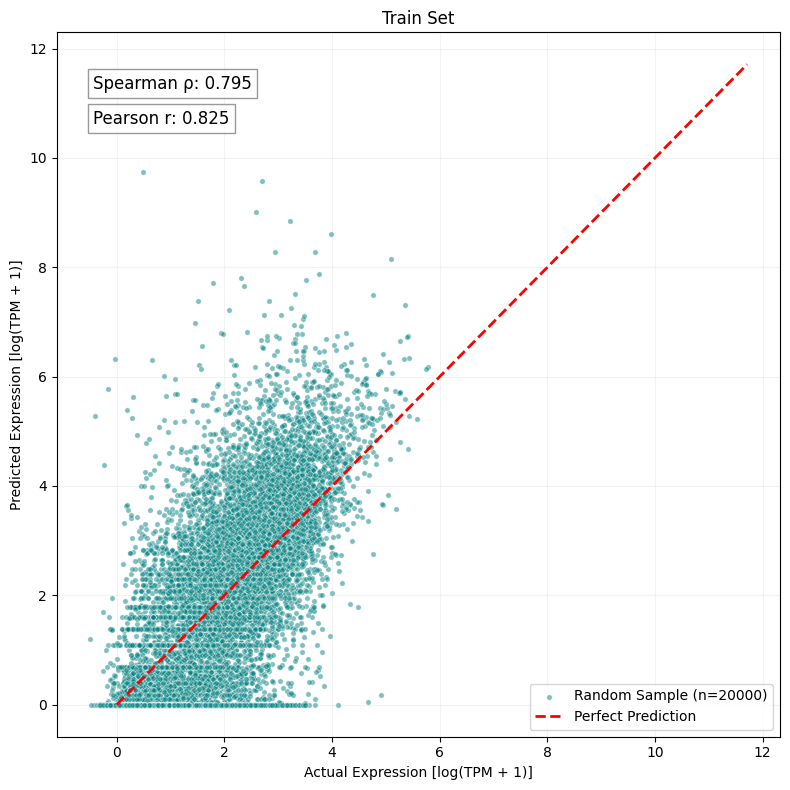

In [79]:
plot_expression_predictions(train_tar, train_pred, title='Train Set', 
                            sample_size=20000)